<a href="https://colab.research.google.com/github/olesiamoiseenko/sustained_infants_attention_bma/blob/main/Bamojax_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# install bamojax and numpyro if necessary
!pip install numpyro
!pip install git+https://github.com/UncertaintyInComplexSystems/bamojax#egg=bamojax
!pip install jaxopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 4.4 MB/s eta 0:00:00
  Cloning https://github.com/UncertaintyInComplexSystems/bamojax to /tmp/pip-install-de2injpq/bamojax_3b3f6fa7d5c84c2aac8775403d15eb08
  Running command git clone --filter=blob:none --quiet https://github.com/UncertaintyInComplexSystems/bamojax /tmp/pip-install-de2injpq/bamojax_3b3f6fa7d5c84c2aac8775403d15eb08
  Resolved https://github.com/UncertaintyInComplexSystems/bamojax to commit a55e0bd4ba3c741be4239c22256d97a98177ba98
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 2.4 MB/s eta 0:00:00
  Created wheel for bamojax: filename=bamojax-

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)

import jax.random as jrnd
import jax.numpy as jnp
from jax.scipy.stats import gaussian_kde


import blackjax
import numpyro as npr
import numpyro.distributions as dist
import numpyro.distributions.transforms as nprb
import numpyro.distributions.constraints as constraints
from numpyro.distributions.transforms import Transform

import sys

import bamojax
from bamojax.base import Model
from bamojax.samplers import mcmc_sampler, gibbs_sampler
from bamojax.inference import SMCInference, MCMCInference
from bamojax.marginal_likelihoods.bridge_sampling import bridge_sampling
from bamojax.marginal_likelihoods.thames import thames


print('Python version:     ', sys.version)
print('Jax version:        ', jax.__version__)
print('BlackJax version:   ', blackjax.__version__)
print('Bamojax version:    ', bamojax.__version__)
print('Numpyro version:    ', npr.__version__)
print('Jax default backend:', jax.default_backend())
print('Jax devices:        ', jax.devices())

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)             # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)       # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)       # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)       # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)       # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)      # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)     # fontsize of the figure title

Python version:      3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Jax version:         0.10.1
BlackJax version:    1.5
Bamojax version:     0.3.12+1.ga55e0bd
Numpyro version:     0.21.0
Jax default backend: cpu
Jax devices:         [CpuDevice(id=0)]


### Load data

In [ ]:
data = jnp.load('processed_data.npz')

Y = data['LA_matrix']
exposure_matrix = data['exposure_matrix']       # {0, 1}
kl_matrix = data['kl_matrix']                   # [0, 0.08]
sequence_matrix = data['sequence_matrix']       # [0, 1]
condition_matrix = data['condition_matrix']     # {0, 1}

X = jnp.stack([kl_matrix,                                                           # 0
               sequence_matrix,                                                     # 1
               condition_matrix]).transpose([1, 2, 3, 0])                                                   # 2

varnames = ['IG', 'Seq', 'Cond']
# varnames = ['IG', 'Seq', 'Cond', 'IG*Seq', 'IG*Cond', 'Seq*Cond', 'IG*Seq*Cond']

print('X.shape:', X.shape)
N, S, T, D = X.shape

X.shape: (80, 12, 25, 3)


## Generate different models

Models consist of different subsets of predictors and interaction effects.

In [ ]:
from itertools import combinations, product
# some of these helper functions to enumerate all models were generated by chatgpt

def interaction_models(features, max_order=None, include_empty=True, hierarchical=True):
    """
    Generate all models consisting of:
      - a subset of `features` as main effects
      - any combination of valid interaction effects (subsets of those mains)

    With `hierarchical=True`, any k-way interaction is only allowed if
    all its lower-order interactions (of size >= 2) built from the same
    variables are also included.

    Each model is a list:
        [main1, main2, ..., [i, j], [i, j, k], ...]
    """
    features = list(features)
    n = len(features)
    if max_order is None:
        max_order = n

    models = []
    start_r = 0 if include_empty else 1

    for r in range(start_r, n + 1):
        for mains in combinations(features, r):
            mains = list(mains)

            # All potential interaction terms for this set of mains
            inter_terms = [
                list(c)
                for order in range(2, min(max_order, len(mains)) + 1)
                for c in combinations(mains, order)
            ]

            m = len(inter_terms)

            # For each interaction, choose include/exclude (0/1)
            for mask in product([0, 1], repeat=m):
                chosen_inters = [
                    term for bit, term in zip(mask, inter_terms) if bit
                ]

                if hierarchical and chosen_inters:
                    chosen_set = {tuple(term) for term in chosen_inters}
                    valid = True
                    # Enforce: if a higher-order interaction is present,
                    # all its lower-order (>=2) subsets must also be present.
                    for term in chosen_inters:
                        if len(term) <= 2:
                            continue
                        for order in range(2, len(term)):
                            for sub in combinations(term, order):
                                if tuple(sub) not in chosen_set:
                                    valid = False
                                    break
                            if not valid:
                                break
                        if not valid:
                            break
                    if not valid:
                        continue  # skip this model

                models.append(mains + chosen_inters)

    return models

#
def build_design_matrix(X, model):
    """
    Given:
      - X: array with shape (..., D), e.g. (N, S, T, D)
      - model: list like [0, 1, 2, [0, 1], [0, 2], [1, 2], [0, 1, 2]]

    Returns:
      - design: array with shape (..., P) where P = #mains + #interactions
        The leading dimensions (e.g. N, S, T) are unchanged.
    """
    *batch_dims, d = X.shape   # e.g. [N, S, T], d = D

    # Separate main effects and interaction terms
    mains = [m for m in model if not isinstance(m, (list, tuple))]
    inters = [m for m in model if isinstance(m, (list, tuple))]

    cols = []

    # Add main effect "columns" (last dimension)
    for j in mains:
        # Keep dims so result has shape (..., 1)
        cols.append(X[..., j:j+1])

    # Add interaction effects as products over selected features
    for term in inters:
        idx = list(term)
        # X[..., idx] has shape (..., k); product over the last axis
        col = jnp.prod(X[..., idx], axis=-1, keepdims=True)  # (..., 1)
        cols.append(col)

    if cols:
        # Concatenate along the last axis (feature dimension)
        design = jnp.concatenate(cols, axis=-1)  # shape (..., P)
    else:
        # Null model: no columns, keep batch dims
        design = jnp.zeros(batch_dims + [0], dtype=X.dtype)

    return design

#
def build_all_design_matrices(X, models):
    """
    Apply build_design_tensor to a list of models.

    Parameters
    ----------
    X : array with shape (..., D), e.g. (N, S, T, D)
    models : list of models (each a list as above)

    Returns
    -------
    list of arrays, each with shape (..., P_k)
    """
    return [build_design_matrix(X, model) for model in models]

#
def index2name(ix):
    model = models[ix]
    name = ''
    main_effects = list(filter(lambda x: isinstance(x, int), model))
    name += ', '.join([varnames[i] for i in main_effects])

    interaction_effects = list(filter(lambda x: isinstance(x, list) and len(x)==2, model))
    if len(interaction_effects) > 0:
        name += ', '
        int_effects_string_list = []
        for int_ef in interaction_effects:
            int_effects_string_list.append(f'{varnames[int_ef[0]]}*{varnames[int_ef[1]]}')
        name += ', '.join([str(i) for i in int_effects_string_list])


    if [0, 1, 2] in model:
        name += ', ' + f'{varnames[0]}*{varnames[1]}*{varnames[2]}'

    if name == '':
        name = 'Null'
    return name

#
def ix2term(ix):
    if isinstance(ix, int):
        return varnames[ix]
    elif len(ix) == 2:
        return f'{varnames[ix[0]]}*{varnames[ix[1]]}'
    else:
        return f'{varnames[ix[0]]}*{varnames[ix[1]]}*{varnames[ix[2]]}'

#

models = interaction_models([0, 1, 2])
num_models = len(models)
for i, m in enumerate(models):
    print(f'Model index: {i}, contents: {index2name(i)}')

all_design_matrices = build_all_design_matrices(X, models)

Model index: 0, contents: Null
Model index: 1, contents: IG
Model index: 2, contents: Seq
Model index: 3, contents: Cond
Model index: 4, contents: IG, Seq
Model index: 5, contents: IG, Seq, IG*Seq
Model index: 6, contents: IG, Cond
Model index: 7, contents: IG, Cond, IG*Cond
Model index: 8, contents: Seq, Cond
Model index: 9, contents: Seq, Cond, Seq*Cond
Model index: 10, contents: IG, Seq, Cond
Model index: 11, contents: IG, Seq, Cond, Seq*Cond
Model index: 12, contents: IG, Seq, Cond, IG*Cond
Model index: 13, contents: IG, Seq, Cond, IG*Cond, Seq*Cond
Model index: 14, contents: IG, Seq, Cond, IG*Seq
Model index: 15, contents: IG, Seq, Cond, IG*Seq, Seq*Cond
Model index: 16, contents: IG, Seq, Cond, IG*Seq, IG*Cond
Model index: 17, contents: IG, Seq, Cond, IG*Seq, IG*Cond, Seq*Cond
Model index: 18, contents: IG, Seq, Cond, IG*Seq, IG*Cond, Seq*Cond, IG*Seq*Cond


### Plotting utility

In [ ]:
def plot_coefficients(samples, names, suptitle=None):

    def plot_one_chain(ax, x, color):
        pdf = gaussian_kde(x)
        beta_min, beta_max = jnp.quantile(x, q=jnp.array([0.001, 0.999]))
        beta_lb, beta_ub = jnp.quantile(x, q=jnp.array([0.025, 0.975]))
        beta_range = jnp.linspace(beta_min, beta_max, num=200)
        ax.plot(beta_range, pdf(beta_range), color=color)
        for b_intv in [beta_lb, beta_ub]:
            ax.axvline(x=b_intv, ls=':', color=color)

    #

    betas = samples['beta']
    multiple_chains = jnp.ndim(betas) == 3
    D = betas.shape[-1]

    if D > 1:
        _, axes = plt.subplots(nrows=1, ncols=D, constrained_layout=True, figsize=(4*D, 3))
        for d in range(D):
            if multiple_chains:
                colors = plt.cm.Blues(jnp.linspace(0, 1, betas.shape[0]))
                for c in range(betas.shape[0]):
                    plot_one_chain(axes[d], betas[c, :, d], color=colors[c, :])
            else:
                plot_one_chain(axes[d], betas[:, d], color='tab:blue')
            axes[d].set_title(f'{names[d]}', fontsize=MEDIUM_SIZE)
            axes[d].set_ylim(bottom=0)
            axes[d].set_xlabel(r'$\beta$', fontsize=SMALL_SIZE)

        if suptitle == None:
            suptitle = 'Predictor impact'
        plt.suptitle(suptitle, fontsize=BIGGER_SIZE)
    else:
        plt.figure(figsize=(4, 3))
        ax = plt.gca()
        if multiple_chains:
            colors = plt.cm.Blues(jnp.linspace(0, 1, betas.shape[0]))
            for c in range(betas.shape[0]):
                plot_one_chain(ax, jnp.squeeze(betas[c, ...]), color=colors[c, :])
        else:
            plot_one_chain(ax, betas, color='tab:blue')
        ax.set_title(suptitle, fontsize=MEDIUM_SIZE)
        ax.set_ylim(bottom=0)
        ax.set_xlabel(r'$\beta$', fontsize=SMALL_SIZE)

    plt.show()

#

## Model setup

### Baseline model: Cox proportional hazards

Our first model is a Cox proportional hazards with piece-wise independent hazard rates $h_0(t)\sim \text{Gamma}(0.1, 0.1)$, all predictors included, as well as the interaction term between the information gain and social condition.

Variants of the model contain subsets of predictors.

In [ ]:
def setup_cph_model(X, Y, exposure_matrix, name='CPH'):

    def cph_link_fn(h0, beta, E, X):
        """ The Cox proportional hazards link function.

        """
        mu = jnp.tensordot(beta, X, axes=[0, 3])
        lambda_ = E * h0 * jnp.exp(mu) + 1e-20
        # In contrast to e.g. PyMC, the Numpyro Poisson distribution does not return 0 for exp(poisson.logprob(0)) for a rate of 0, which gives trouble here.
        # We can fix this with some jitter, or we can inherit the Poisson distribution and override the log_prob
        return dict(rate=lambda_)

    #
    _, _, T, D = X.shape

    cph_model = Model(name)
    h0_node = cph_model.add_node('h0', distribution=dist.Gamma(concentration=0.1, rate=0.1), shape=(T, ))
    beta_node = cph_model.add_node('beta', distribution=dist.Normal(loc=0.0, scale=1.0), shape=(D, ))
    input_node = cph_model.add_node('X', observations=X)
    exposure_node = cph_model.add_node('E', observations=exposure_matrix)
    obs_node = cph_model.add_node('Y', distribution=dist.Poisson, observations=Y,
                                parents=dict(h0=h0_node,
                                            beta=beta_node,
                                            E=exposure_node,
                                            X=input_node),
                                link_fn=cph_link_fn)
    return cph_model

#
def setup_cph_null_model(Y, exposure_matrix, name):

    def cph_link_fn(h0, E):
        """ The Cox proportional hazards link function.

        """
        lambda_ = E * h0 * jnp.exp(0) + 1e-20
        # In contrast to e.g. PyMC, the Numpyro Poisson distribution does not return 0 for exp(poisson.logprob(0)) for a rate of 0, which gives trouble here.
        # We can fix this with some jitter, or we can inherit the Poisson distribution and override the log_prob
        return dict(rate=lambda_)

    #
    _, _, T = Y.shape

    cph_model = Model(name)
    h0_node = cph_model.add_node('h0', distribution=dist.Gamma(concentration=0.1, rate=0.1), shape=(T, ))
    exposure_node = cph_model.add_node('E', observations=exposure_matrix)
    obs_node = cph_model.add_node('Y', distribution=dist.Poisson, observations=Y,
                                parents=dict(h0=h0_node,
                                            E=exposure_node),
                                link_fn=cph_link_fn)
    return cph_model

#

cph_models = []
cph_models.append(setup_cph_null_model(Y, exposure_matrix, 'CPH_Null'))

for m in range(1, num_models):
    cph_models.append(setup_cph_model(all_design_matrices[m], Y, exposure_matrix, f'CPH_{m}'))

for cph_model in cph_models:
    print(cph_model.name)

CPH_Null
CPH_1
CPH_2
CPH_3
CPH_4
CPH_5
CPH_6
CPH_7
CPH_8
CPH_9
CPH_10
CPH_11
CPH_12
CPH_13
CPH_14
CPH_15
CPH_16
CPH_17
CPH_18


In [ ]:
cph_model

## Posterior inference

In [ ]:
def estimate_posterior(key, model: Model, num_samples: int = 2000, num_warmup: int = 1000, num_chains: int = 4, num_thin: int = 1):
    m = model.get_model_size()
    cold_nuts_parameters = dict(step_size=0.5, inverse_mass_matrix=0.0001*jnp.eye(m))  # these will be overriden by the window adaptation
    nuts_kernel = mcmc_sampler(model=model, mcmc_kernel=blackjax.nuts, mcmc_parameters=cold_nuts_parameters)
    engine = MCMCInference(model=model, mcmc_kernel=nuts_kernel, num_samples=num_samples, num_burn=0, num_warmup=num_warmup, num_thin=num_thin, num_chains=num_chains)
    results = engine.run(key)
    return results

#

In [ ]:
def get_posterior(key, model: Model, load_from_disk: bool = True, suffix='', num_samples=2_000, num_warmup=1_000):
    filename = f'samples/samples_CPH_{suffix}.npz'
    if load_from_disk and os.path.exists(filename):
        print('Loading samples from disk')
        posterior_samples = jnp.load(filename, allow_pickle=True)['samples'].item()
    elif load_from_disk==False:
        posterior_samples = jnp.load(filename, allow_pickle=True)['samples'].item()
    else:
        print(f'no samples for model {model.name}, index {suffix}')
        # NUTS is much faster on CPU, so we force that device
        cpu = jax.devices('cpu')[0]
        def run_on_cpu(fn, *args, **kwargs):
            args_cpu = jax.tree.map(lambda x: jax.device_put(x, cpu) if isinstance(x, jnp.ndarray) else x, args)
            kwargs_cpu = jax.tree.map(lambda x: jax.device_put(x, cpu) if isinstance(x, jnp.ndarray) else x, kwargs)

            with jax.default_device(cpu):
                out = fn(*args_cpu, **kwargs_cpu)
            return out

        print('Starting NUTS inference')
        num_thin = int(num_samples / 2_000)
        num_chains = 4
        results = run_on_cpu(estimate_posterior, key, model, num_samples=num_samples, num_chains=num_chains, num_thin=num_thin, num_warmup=num_warmup)
        posterior_samples = results['states']
        jnp.savez(filename, samples=posterior_samples)
    return posterior_samples

#

In [ ]:
key = jrnd.PRNGKey(0)
posterior_samples = []

for m in range(num_models):
    cph_model = cph_models[m]
    print(f'Sampling model {index2name(m)}')
    key, subkey = jrnd.split(key)
    posterior_samples.append(get_posterior(subkey, cph_model, load_from_disk=False, suffix=m))

Sampling model Null
Sampling model IG
Sampling model Seq
Sampling model Cond
Sampling model IG, Seq
Sampling model IG, Seq, IG*Seq
Sampling model IG, Cond
Sampling model IG, Cond, IG*Cond
Sampling model Seq, Cond
Sampling model Seq, Cond, Seq*Cond
Sampling model IG, Seq, Cond
Sampling model IG, Seq, Cond, Seq*Cond
Sampling model IG, Seq, Cond, IG*Cond
Sampling model IG, Seq, Cond, IG*Cond, Seq*Cond
Sampling model IG, Seq, Cond, IG*Seq
Sampling model IG, Seq, Cond, IG*Seq, Seq*Cond
Sampling model IG, Seq, Cond, IG*Seq, IG*Cond
Sampling model IG, Seq, Cond, IG*Seq, IG*Cond, Seq*Cond
Sampling model IG, Seq, Cond, IG*Seq, IG*Cond, Seq*Cond, IG*Seq*Cond


In [ ]:
# in case some model does not converge with standard settings, we can run for longer here.

key = jrnd.PRNGKey(1234)

redo_indices = []

for redo_ix in redo_indices:
    print(cph_models[redo_ix].name)
    key, subkey = jrnd.split(key)
    posterior_samples[redo_ix] = get_posterior(subkey, cph_models[redo_ix], load_from_disk=False, num_samples=8_000, num_warmup=2_000)

## Convergence diagnostics

Check for convergence for all models by computing the Potential scale Reduction Factor ($\hat{R}$; Gelman & Rubin).

In [ ]:
from blackjax.diagnostics import potential_scale_reduction

for ix, cph_model, samples in zip(jnp.arange(len(cph_models)), cph_models, posterior_samples):
    max_Rhat = 1.0
    for k, v in samples.items():
        R = potential_scale_reduction(v)
        max_Rhat_k = jnp.max(R.flatten())
        if max_Rhat_k > max_Rhat:
            max_Rhat = max_Rhat_k
    print(f'Model {ix:2}, max. R_hat: {max_Rhat:0.3f}')

Model  0, max. R_hat: 1.002
Model  1, max. R_hat: 1.001
Model  2, max. R_hat: 1.002
Model  3, max. R_hat: 1.001
Model  4, max. R_hat: 1.001
Model  5, max. R_hat: 1.001
Model  6, max. R_hat: 1.004
Model  7, max. R_hat: 1.001
Model  8, max. R_hat: 1.001
Model  9, max. R_hat: 1.004
Model 10, max. R_hat: 1.001
Model 11, max. R_hat: 1.002
Model 12, max. R_hat: 1.001
Model 13, max. R_hat: 1.003
Model 14, max. R_hat: 1.001
Model 15, max. R_hat: 1.003
Model 16, max. R_hat: 1.004
Model 17, max. R_hat: 1.002
Model 18, max. R_hat: 1.004


## Model comparison and marginal likelihood estimation

We compare two marginal likelihood estimators, Bridge Sampling and THAMES, just to make sure this process goes well. They agree very well, so we only use THAMES in the analyses below.

In [ ]:
def lml_thames_estimate(key, model: Model, samples):
    samples_merged = jax.tree.map(lambda x: jnp.reshape(x, shape=(x.shape[0]*x.shape[1], -1)), samples)
    lml_merged = thames(key, model, samples_merged)
    return lml_merged

#
def lml_bridge_sampling_estimate(key, model: Model, samples, bijectors, N2=1000):
    samples_merged = jax.tree.map(lambda x: jnp.reshape(x, shape=(x.shape[0]*x.shape[1], -1)), samples)

    bridge_sampling_estimate, _ = bridge_sampling(key=key,
                                                  model=model,
                                                  posterior_samples=samples_merged,
                                                  bijectors=bijectors,
                                                  proposal_type='gaussian',
                                                  N2=N2)
    return bridge_sampling_estimate

#

In [ ]:
log_marginal_likelihoods_thames = []
log_marginal_likelihoods_bs = []

cph_bijectors = dict(h0=nprb.ExpTransform())

key = jrnd.PRNGKey(1)

for cph_model, samples in zip(cph_models, posterior_samples):
    key, subkey = jrnd.split(key)
    print(f'Model {cph_model.name}')
    thames_lml = lml_thames_estimate(subkey, cph_model, samples)
    log_marginal_likelihoods_thames.append(thames_lml)

    print(f'THAMES LML: {thames_lml:0.3f}')

    key, subkey = jrnd.split(key)
    bs_lml = lml_bridge_sampling_estimate(subkey, cph_model, samples, cph_bijectors)
    log_marginal_likelihoods_bs.append(bs_lml)

    print(f'BS LML: {bs_lml:0.3f}')

Model CPH_Null
THAMES LML: -2837.570
BS LML: -2837.576
Model CPH_1
THAMES LML: -2830.921
BS LML: -2830.973
Model CPH_2
THAMES LML: -2707.315
BS LML: -2707.283
Model CPH_3
THAMES LML: -2828.840
BS LML: -2828.805
Model CPH_4
THAMES LML: -2704.588
BS LML: -2704.522
Model CPH_5
THAMES LML: -2698.829
BS LML: -2698.909
Model CPH_6
THAMES LML: -2825.267
BS LML: -2824.202
Model CPH_7
THAMES LML: -2823.964
BS LML: -2824.137
Model CPH_8
THAMES LML: -2709.859
BS LML: -2709.912
Model CPH_9
THAMES LML: -2690.466
BS LML: -2690.461
Model CPH_10
THAMES LML: -2707.108
BS LML: -2707.106
Model CPH_11
THAMES LML: -2689.279
BS LML: -2689.402
Model CPH_12
THAMES LML: -2708.534
BS LML: -2708.214
Model CPH_13
THAMES LML: -2689.449
BS LML: -2689.639
Model CPH_14
THAMES LML: -2701.381
BS LML: -2701.518
Model CPH_15
THAMES LML: -2686.872
BS LML: -2686.901
Model CPH_16
THAMES LML: -2702.860
BS LML: -2702.964
Model CPH_17
THAMES LML: -2686.455
BS LML: -2686.467
Model CPH_18
THAMES LML: -2685.802
BS LML: -2685.730


In [ ]:
jnp.corrcoef(jnp.array(log_marginal_likelihoods_bs), jnp.array(log_marginal_likelihoods_thames))

Array([[1.       , 0.9999906],
       [0.9999906, 1.       ]], dtype=float64)

Convert log marginal likelihoods into posterior model probabilities $P(\mathcal{M} \mid X, Y, E)$.

In [ ]:
from scipy.special import logsumexp

lml = jnp.array(log_marginal_likelihoods_thames)
pmp = jnp.exp(lml - logsumexp(lml))

## Parameter distributions

For all models except the null model, plot the coefficients. The posterior model probability and the included predictors are shown in the title.

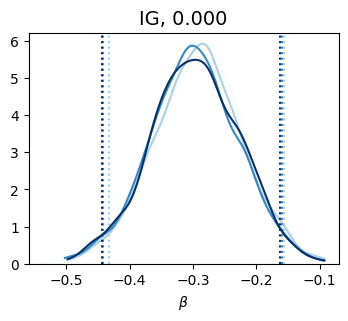

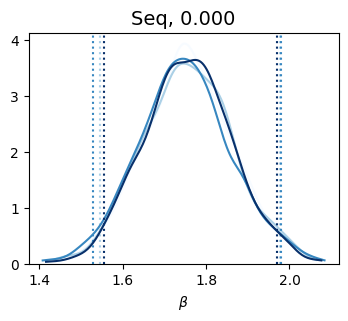

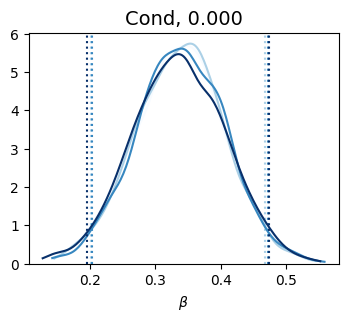

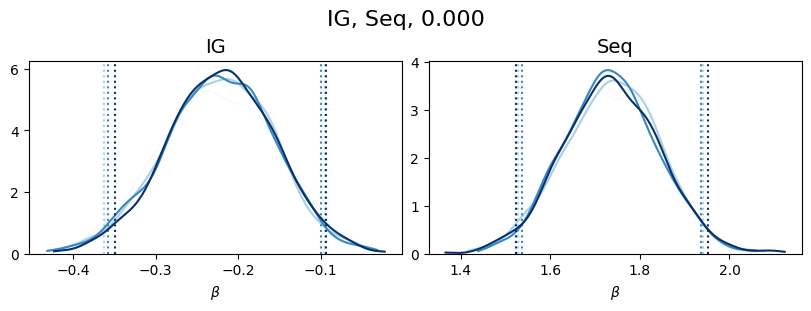

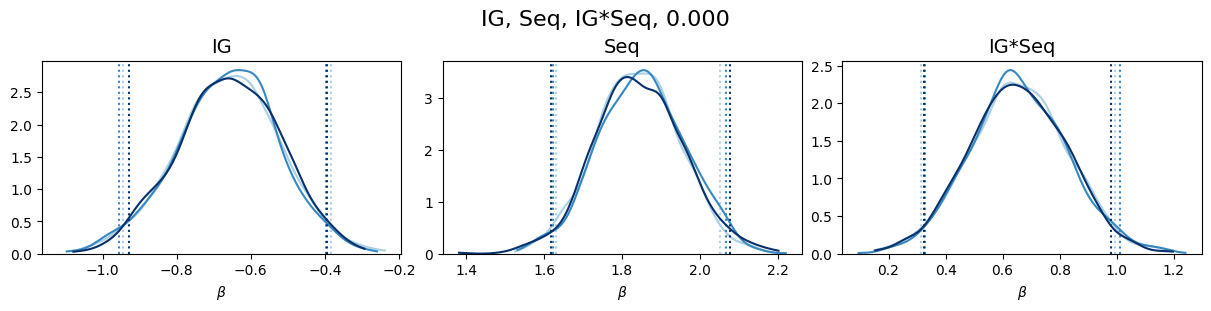

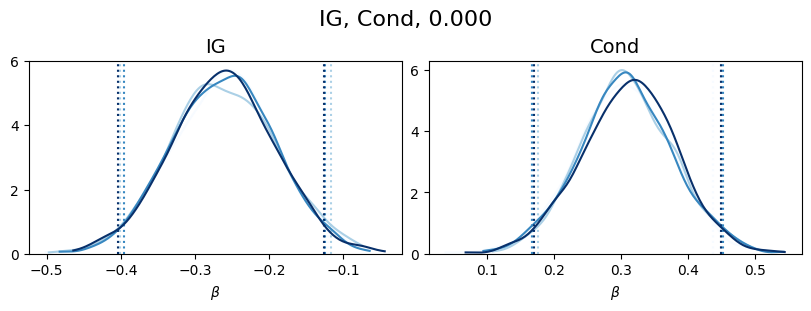

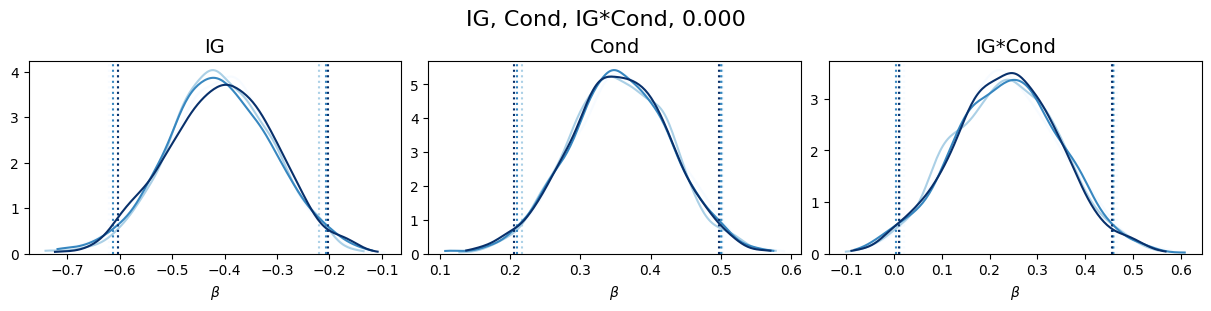

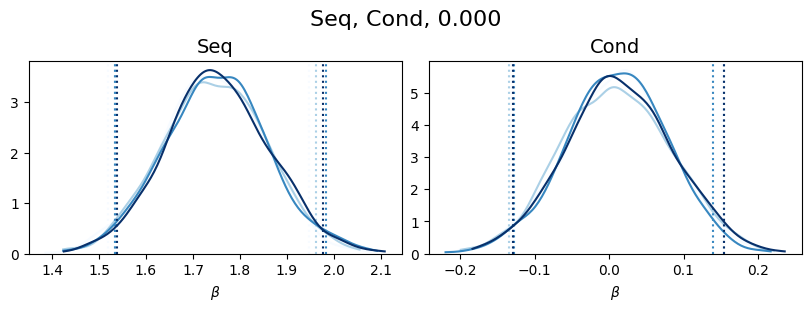

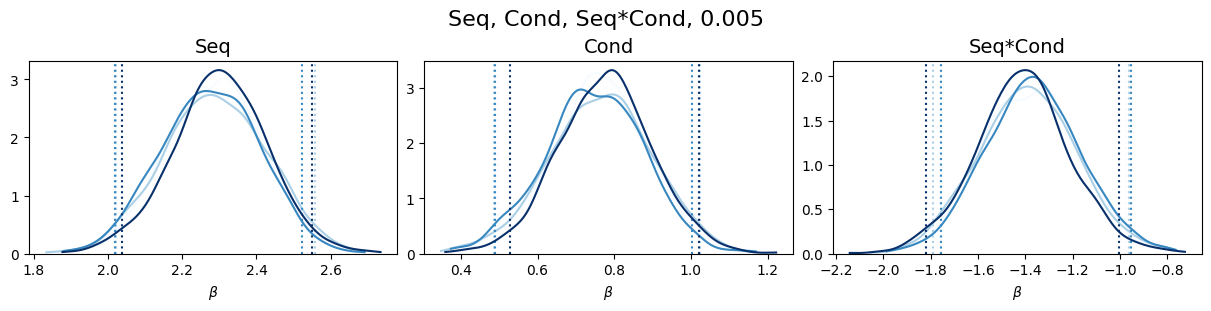

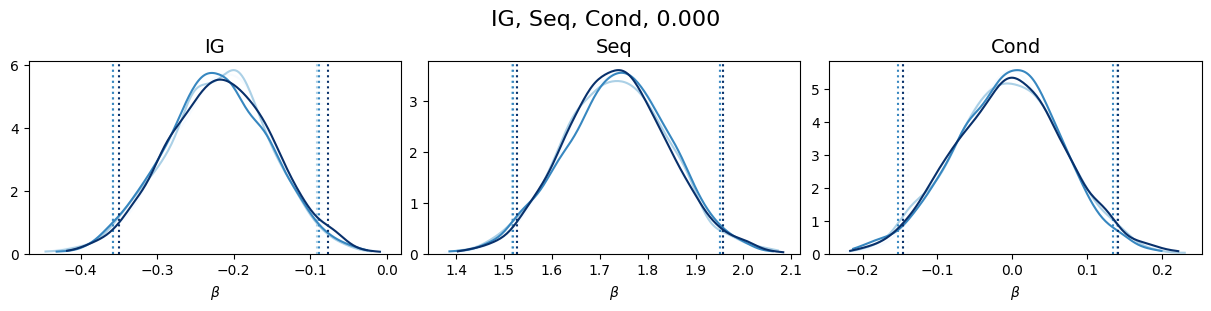

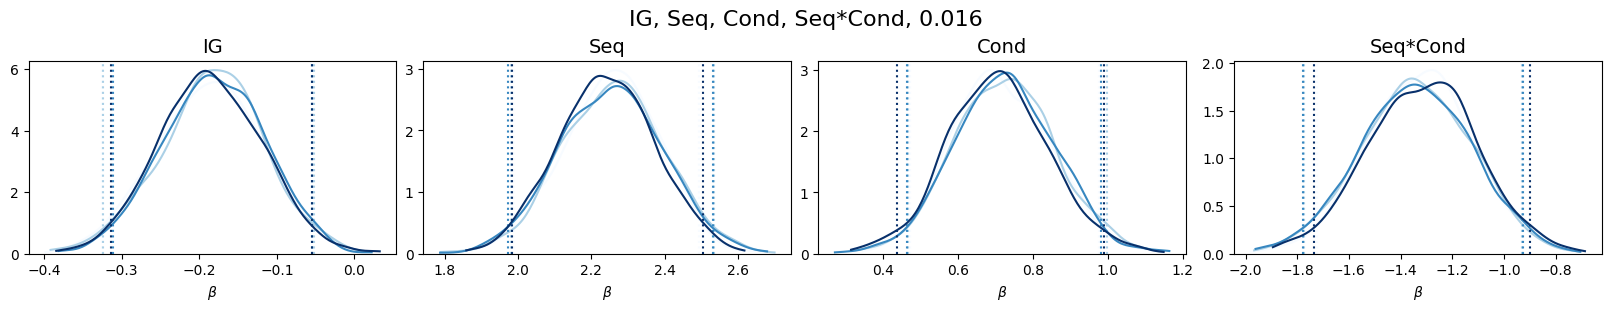

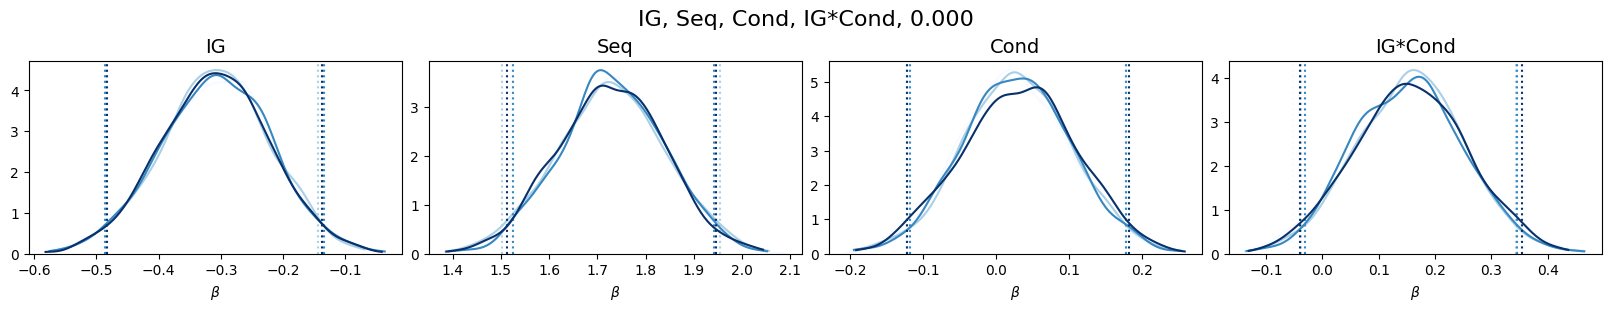

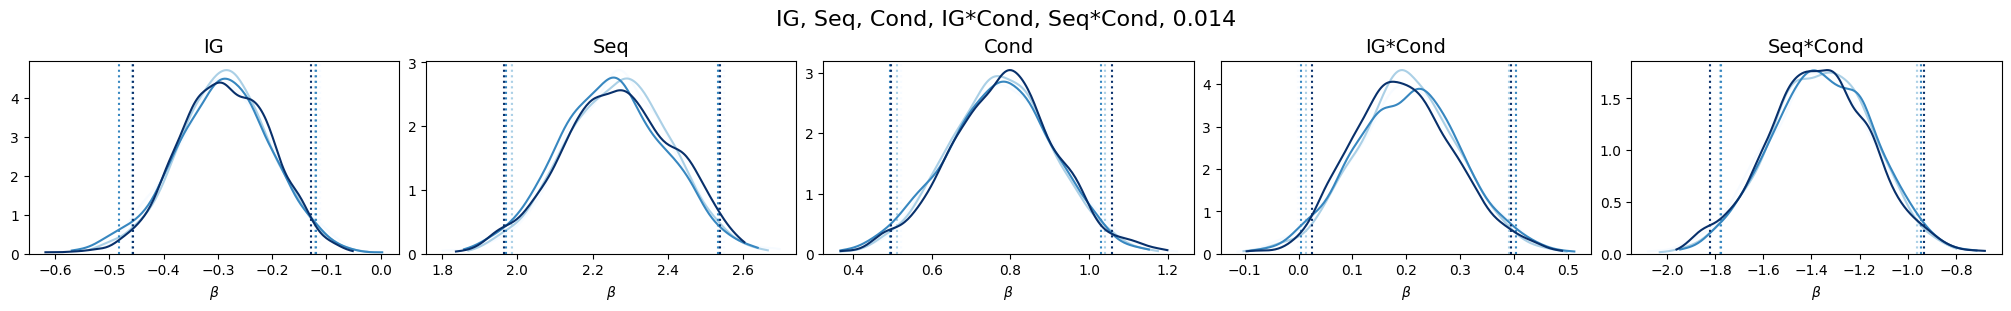

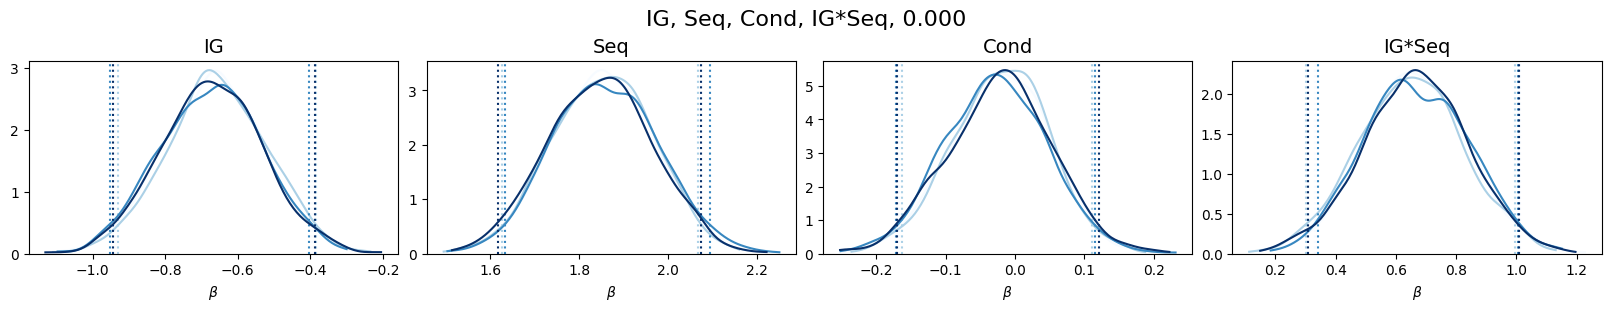

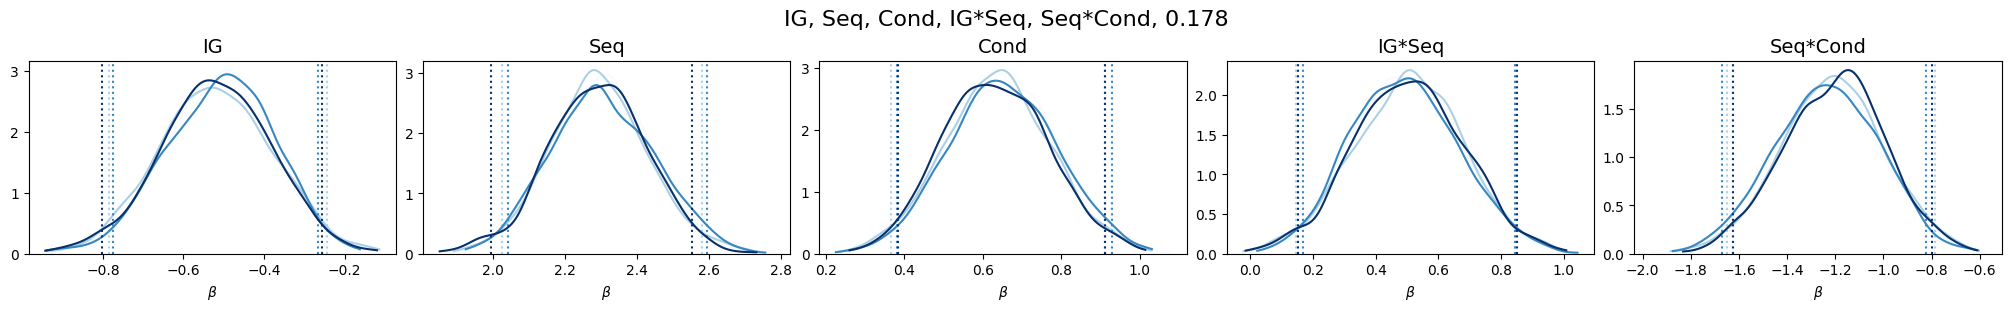

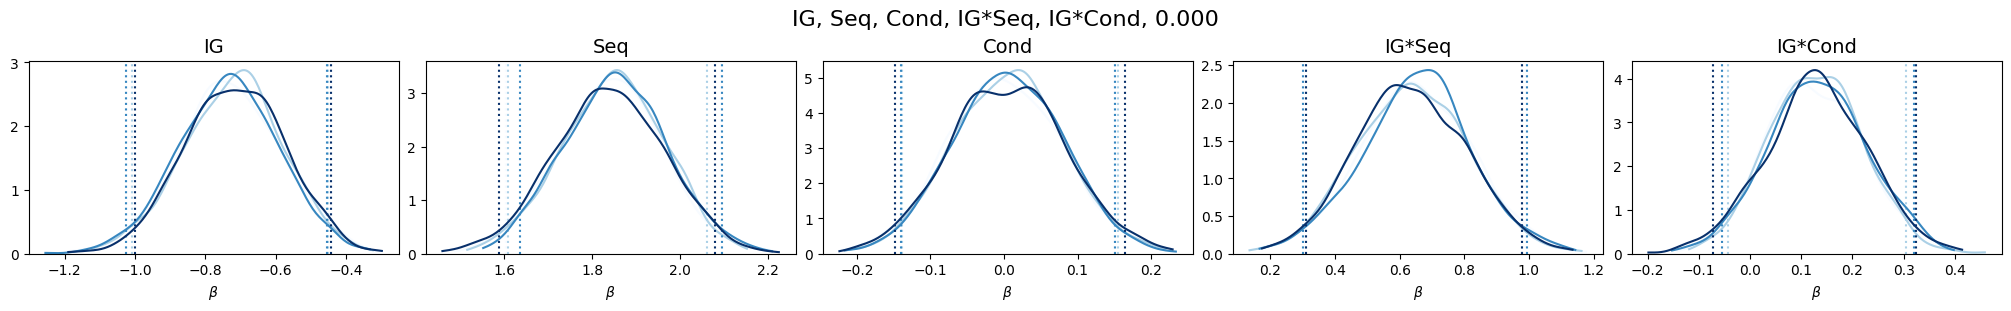

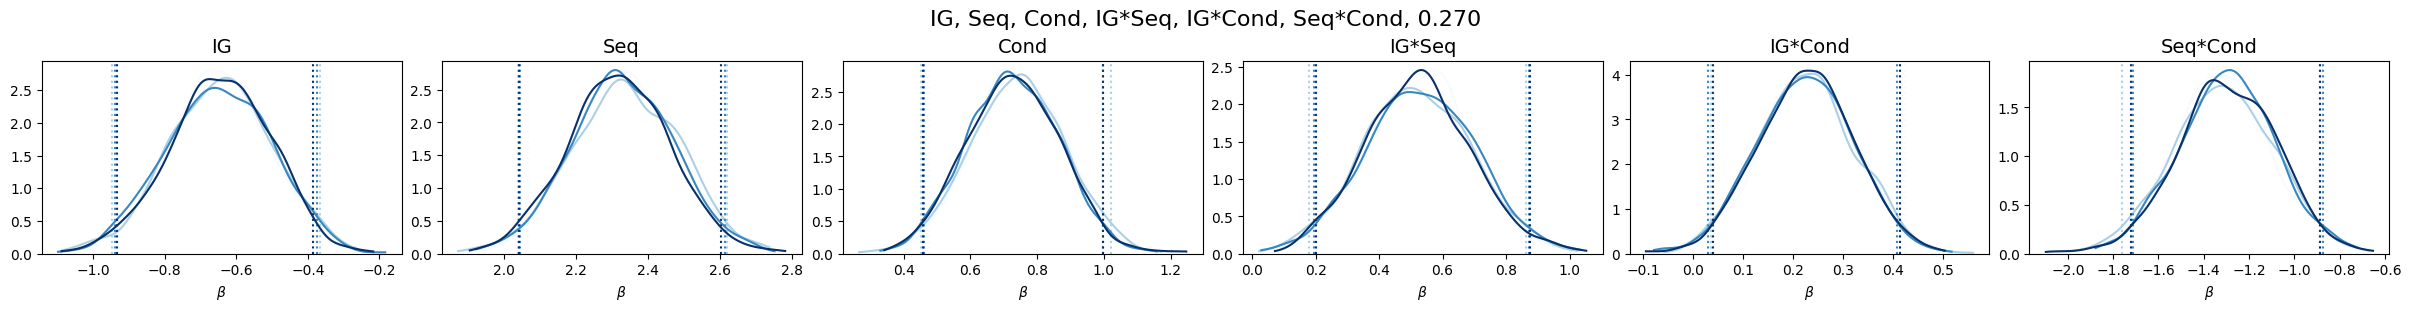

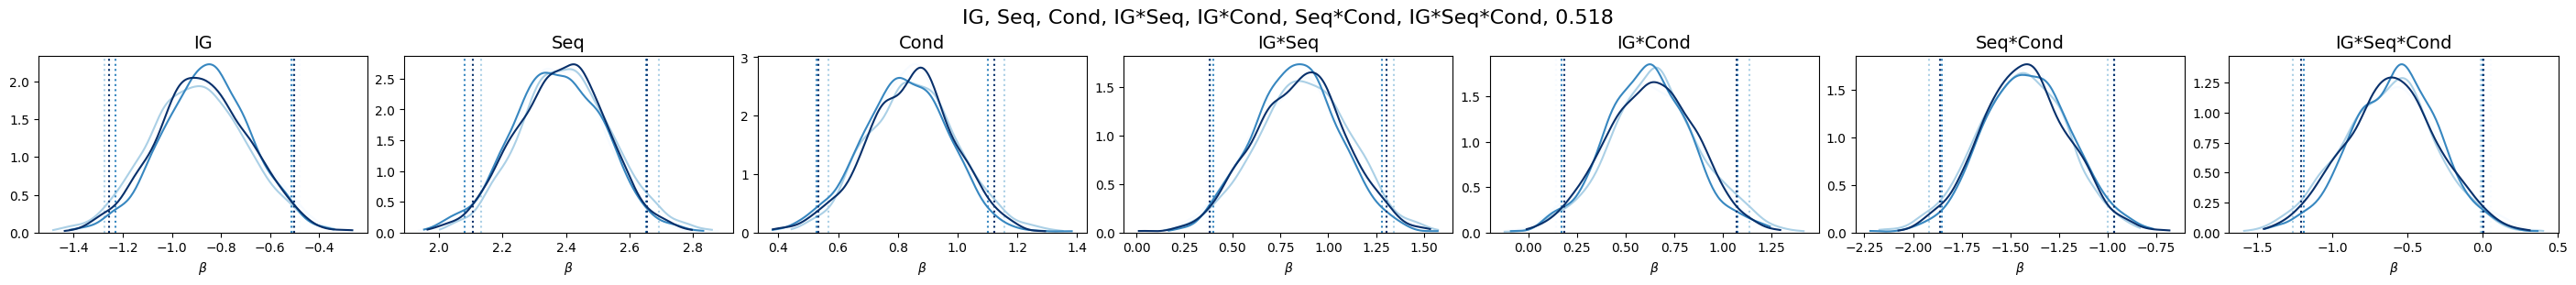

In [ ]:
for ix, cph_model, samples in zip(jnp.arange(len(cph_models)), cph_models, posterior_samples):
    if 'beta' in samples:
        title = index2name(ix)
        elements = [ix2term(el) for el in models[ix]]
        title = ', '.join(map(str, elements)) + f', {pmp[ix]:0.3f}'
        plot_coefficients(samples, elements, suptitle=title)

## Bayesian model averaging

We then compute the Bayesian model averaging. First, for all models we show:

1. Its _prior model probability_ (simply $1/Q$, with $Q=19$ the number of models in total).
2. Its _posterior model probability_, which we obtained via the log marginal likelihoods.
3. The _log Bayes factor_ of the best model (highest marginal likelihood) vs the i-th model. This number is always non-negative.

The models are sorted by their posterior model probability (cq. in reverse order by their Bayes factor vs the top model).

We then compute for each term (predictor, interaction, or three-way effect):

1. Its _prior inclusion probability_, that is, we count in how many models the term is present, and weigh each count by the prior model probability.
2. Its _posterior inclusion probability_, the same as before but now weighted by posterior model probability.
3. Its inclusion log Bayes factor: the (logarithm of the) summed marginal likelihoods of models that include the term, divided by the summed marginal likelihoods that exclude the term.

See Hinne et al, 2020, for a tutorial on the BMA approach.

In [ ]:
sorted_ix = jnp.argsort(lml, descending=True)
M = len(cph_models)

model_prior = str(jnp.round(1/M, 3))
headers = ['Model', 'P(M)', 'P(M|data)', 'log BF_tj']

print(f'{headers[0]:60s} {headers[1]:10s} {headers[2]:15s} {headers[3]:10s}')

for ix in sorted_ix:
    title = index2name(ix)
    pmp_str = str(f'{pmp[ix]:0.3f}')
    log_bf_top_j = lml[sorted_ix[0]] - lml[ix]
    log_bf_top_j_str = str(f'{log_bf_top_j:0.3f}')
    print(f'{title:60s} {model_prior:10s} {pmp_str:15s} {log_bf_top_j_str:15s}')

print('')

terms = models[18]
num_terms = len(terms)

prior_inclusion_prob = jnp.zeros((num_terms, ))
posterior_inclusion_prob = jnp.zeros((num_terms, ))

print('Effect               P(incl)    P(incl|data)    log BF_incl')

for ix, pred in enumerate(terms):
    ix_included = []
    ix_excluded = []
    for m, model in enumerate(models):
        if pred in model:
            prior_inclusion_prob = prior_inclusion_prob.at[ix].add(1/M)
            posterior_inclusion_prob = posterior_inclusion_prob.at[ix].add(pmp[m])
            ix_included.append(m)
        else:
            ix_excluded.append(m)

    inc_bf = jnp.round(logsumexp(lml[jnp.array(ix_included)]) - logsumexp(lml[jnp.array(ix_excluded)]), 3)

    prior_incl = jnp.round(prior_inclusion_prob[ix], 3)
    post_incl = jnp.round(posterior_inclusion_prob[ix], 3)
    term_name = ix2term(pred)
    print(f'{term_name:20s} {str(prior_incl):10.6} {str(post_incl):15.6} {str(inc_bf):10.6}')

Model                                                        P(M)       P(M|data)       log BF_tj 
IG, Seq, Cond, IG*Seq, IG*Cond, Seq*Cond, IG*Seq*Cond        0.053      0.518           0.000          
IG, Seq, Cond, IG*Seq, IG*Cond, Seq*Cond                     0.053      0.270           0.653          
IG, Seq, Cond, IG*Seq, Seq*Cond                              0.053      0.178           1.070          
IG, Seq, Cond, Seq*Cond                                      0.053      0.016           3.477          
IG, Seq, Cond, IG*Cond, Seq*Cond                             0.053      0.014           3.647          
Seq, Cond, Seq*Cond                                          0.053      0.005           4.664          
IG, Seq, IG*Seq                                              0.053      0.000           13.027         
IG, Seq, Cond, IG*Seq                                        0.053      0.000           15.579         
IG, Seq, Cond, IG*Seq, IG*Cond                               0.053   

## Conclusion

The model containing all terms and all interaction effects is the most likely model, and has about 52% of the total model probability mass. That means that the three-way interaction effect is, according to the model posterior, included about half of the time, and hence has a log Bayes factor of approximately 0 (= Bayes factor of approximately 1).

The interaction effect IG*Cond has the smallest Bayes factor, but $\exp 1.4 = 4.1$ is still considered moderate evidence in many Bayes factor interpretation tables. The other factors are included very convincingly.

## Baseline hazard rate

We see the same results in a different view when we visualize the baseline hazard rates $h_0(t)$. In the null model, $h_0(t)$ has to pull all the weight, and wecan see it has the highest magnitude in this model. If, for example, only IG is included, $h_0(t)$ is still fairly high, which corresponds to more modest log Bayes factor forIG. On the other hand, a model that only includes Seq can already explain a large part of the data, as can be seen from the much lower $h_0(t)$ and the high inclusion Bayes factor for this predictor.

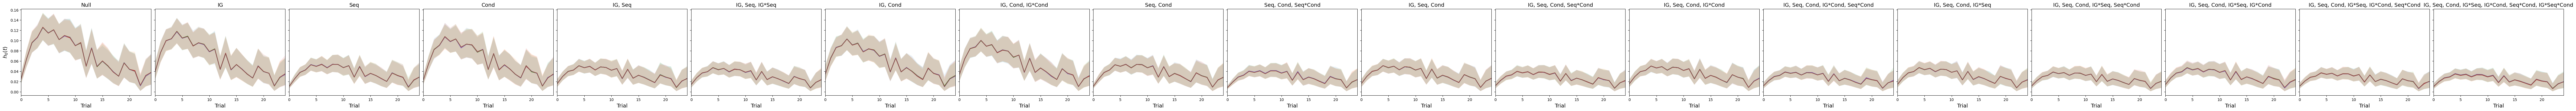

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=num_models, figsize=(5*num_models, 4), constrained_layout=True, sharex=True, sharey=True)

for i, (model, samples) in enumerate(zip(cph_models, posterior_samples)):

    num_chains = samples['h0'].shape[0]
    h0_qs = jnp.quantile(samples['h0'], q=jnp.array([0.025, 0.975]), axis=1)
    h0_mean = jnp.mean(samples['h0'], axis=1)
    h0_range = jnp.arange(T)

    ax = axes[i]
    for c in range(num_chains):
        ax.plot(h0_range, h0_mean.T)
        ax.fill_between(h0_range, h0_qs[0, c, :], h0_qs[1, c, :], alpha=0.1)
    ax.set_xlim([0, T-1])
    ax.set_xlabel('Trial')
    ax.set_title(f'{index2name(i)}', fontsize=MEDIUM_SIZE)

axes[0].set_ylabel(r'$h_0(t)$');